In [1]:
import os, random, math
from pathlib import Path
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib as mpl
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def relative_l2_error_np(gt: np.ndarray, pred: np.ndarray) -> float:
    num = np.linalg.norm(gt - pred)
    den = np.linalg.norm(gt)
    return float(num / (den + 1e-12))

def dataset_rel_l2(model, loader, device, coords):
    model.eval()
    num_sq, den_sq = 0.0, 0.0
    with torch.no_grad():
        for ic, gt in loader:
            ic = ic.to(device)
            gt = gt.to(device)
            pred = model(ic, coords.to(device))
            e = pred - gt
            num_sq += torch.sum(e**2).item()
            den_sq += torch.sum(gt**2).item()
    return math.sqrt(num_sq / (den_sq + 1e-20))

def compute_psnr(gt: np.ndarray, pred: np.ndarray) -> float:
    assert gt.shape == pred.shape
    mse = float(np.mean((gt - pred) ** 2))
    if mse == 0:
        return float('inf')
    data_range = float(gt.max() - gt.min())
    return 10.0 * math.log10((data_range ** 2) / (mse + 1e-20))

def compute_ssim(gt: np.ndarray, pred: np.ndarray) -> float:
    assert gt.shape == pred.shape
    dr = float(gt.max() - gt.min())
    return float(ssim(gt, pred, data_range=dr))

def energy_spectrum_1d(u: np.ndarray, L: float = 1.0):
    N = u.shape[0]
    uh = np.fft.rfft(u)
    k = 2*np.pi*np.fft.rfftfreq(N, d=L/N)
    E = (np.abs(uh)**2) / (N**2)
    return k[1:], E[1:]

def smooth(y, win=5):
    if win <= 1:
        return y
    kernel = np.ones(win)/win
    return np.convolve(y, kernel, mode='same')

data_path = 'Burger.mat'
data_dir = Path(os.path.abspath(data_path)).parent

mat = scipy.io.loadmat(data_path)
u_all = mat['input']
s_all = mat['output']
s_all = s_all[:, :100, :]

N, T, X = s_all.shape
assert u_all.shape[0] == N and u_all.shape[1] == X == 100

X_trainval, X_test, y_trainval, y_test = train_test_split(u_all, s_all, test_size=0.20, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.125, random_state=seed)

mu_ic  = X_train.mean(axis=0, keepdims=True)
std_ic = X_train.std(axis=0, keepdims=True) + 1e-8
mu_sol  = y_train.mean(axis=(0,1), keepdims=True)
std_sol = y_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train_n = (X_train - mu_ic) / std_ic
X_val_n   = (X_val   - mu_ic) / std_ic
X_test_n  = (X_test  - mu_ic) / std_ic
y_train_n = (y_train - mu_sol) / std_sol
y_val_n   = (y_val   - mu_sol) / std_sol
y_test_n  = (y_test  - mu_sol) / std_sol

grid = np.linspace(0.0, 1.0, 100)
Xg, Tg = np.meshgrid(grid, grid, indexing='xy')
coords_np = np.stack([Xg, Tg], axis=-1).astype(np.float32)

class Burgers1DDataset(Dataset):
    def __init__(self, ic, sol, coords):
        self.ic  = torch.tensor(ic, dtype=torch.float32)
        self.sol = torch.tensor(sol, dtype=torch.float32)
        self.coords = torch.tensor(coords, dtype=torch.float32)
    def __len__(self):
        return self.ic.shape[0]
    def __getitem__(self, i):
        return self.ic[i], self.sol[i]

train_ds = Burgers1DDataset(X_train_n, y_train_n, coords_np)
val_ds   = Burgers1DDataset(X_val_n,   y_val_n,   coords_np)
test_ds  = Burgers1DDataset(X_test_n,  y_test_n,  coords_np)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

coords = train_ds.coords.to(device)

class FourierEmbedding(nn.Module):
    def __init__(self, input_dim, mapping_size=256, sigma=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * sigma
        self.register_buffer('B', B)
    def forward(self, x):
        x_proj = 2*math.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkFourier(nn.Module):
    def __init__(self, input_dim=2, mapping_size=256, hidden=256, out_features=100):
        super().__init__()
        self.embed = FourierEmbedding(input_dim, mapping_size=mapping_size, sigma=10.0)
        self.net = nn.Sequential(
            nn.Linear(2*mapping_size, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_features)
        )
    def forward(self, coords):
        x = coords.view(-1, 2)
        x = self.embed(x)
        return self.net(x)

class TrunkMLP(nn.Module):
    def __init__(self, hidden=50, out_features=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_features)
        )
    def forward(self, coords):
        x = coords.view(-1, 2)
        return self.net(x)

class Branch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(100, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 100)
        )
    def forward(self, ic):
        return self.net(ic)

class DeepONet(nn.Module):
    def __init__(self, trunk):
        super().__init__()
        self.branch = Branch()
        self.trunk  = trunk
    def forward(self, ic, coords):
        B = ic.size(0)
        G = coords.size(0)
        trunk_out  = self.trunk(coords)
        branch_out = self.branch(ic)
        y = torch.matmul(branch_out, trunk_out.T)
        return y.view(B, G, G)

fedonet   = DeepONet(TrunkFourier()).to(device)
deeponet  = DeepONet(TrunkMLP()).to(device)

def denorm_sol(y_norm: torch.Tensor) -> torch.Tensor:
    mu = torch.tensor(mu_sol,  dtype=torch.float32, device=y_norm.device)
    sd = torch.tensor(std_sol, dtype=torch.float32, device=y_norm.device)
    return y_norm * sd + mu

def rel_l2_dataset_numpy(pred_all: np.ndarray, gt_all: np.ndarray) -> float:
    rels = [relative_l2_error_np(gt_all[i], pred_all[i]) for i in range(gt_all.shape[0])]
    return float(np.mean(rels))

def predict_fullset(model, loader, device, coords):
    model.eval()
    preds, gts, ics = [], [], []
    with torch.no_grad():
        for ic, gt in loader:
            ic = ic.to(device)
            gt = gt.to(device)
            pred = model(ic, coords.to(device))
            pred_den = denorm_sol(pred).cpu().numpy()
            gt_den   = denorm_sol(gt).cpu().numpy()
            preds.append(pred_den)
            gts.append(gt_den)
            ics.append(ic.cpu().numpy())
    return np.concatenate(ics), np.concatenate(gts), np.concatenate(preds)

def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    run_loss = 0.0
    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)
        optimizer.zero_grad()
        pred = model(ic, coords.to(device))
        loss = criterion(pred, gt)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * ic.size(0)
    return run_loss / len(loader.dataset)

@torch.no_grad()
def val_rel_l2(model, loader, device, coords):
    model.eval()
    num_sq, den_sq = 0.0, 0.0
    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)
        pred = model(ic, coords.to(device))
        pred_d = denorm_sol(pred)
        gt_d   = denorm_sol(gt)
        e = pred_d - gt_d
        num_sq += torch.sum(e**2).item()
        den_sq += torch.sum(gt_d**2).item()
    return math.sqrt(num_sq / (den_sq + 1e-20))

def _resolve_ckpt_path(name: str) -> Path:
    p = data_dir / f"{name}_best.pth"
    p.parent.mkdir(parents=True, exist_ok=True)
    return p

def _safe_save_same_dir(obj, dest_path: Path):
    tmp_path = dest_path.with_suffix(dest_path.suffix + ".tmp")
    with open(tmp_path, "wb") as f:
        torch.save(obj, f)
    if dest_path.exists():
        try:
            os.remove(dest_path)
        except Exception:
            pass
    os.replace(str(tmp_path), str(dest_path))
    return str(dest_path)

def fit_model(model, name, train_loader, val_loader, coords, max_epochs=2000, lr=1e-4,
              patience=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30, verbose=False)
    best_val = float('inf')
    best_path = _resolve_ckpt_path(name)
    print(f"[INFO] Checkpoint will be saved to: {best_path}")
    wait = 0
    hist = {'train_loss': [], 'val_rel_l2': []}
    for epoch in range(1, max_epochs+1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, coords)
        val_r2  = val_rel_l2(model, val_loader, device, coords)
        hist['train_loss'].append(tr_loss)
        hist['val_rel_l2'].append(val_r2)
        scheduler.step(val_r2)
        if epoch % 1000 == 0 or epoch == 1:
            print(f'[{name}] Epoch {epoch:4d}/{max_epochs} | Train MSE(n): {tr_loss:.6e} | Val Rel-L2: {val_r2:.6e}')
        if val_r2 < best_val - 1e-6:
            best_val = val_r2
            _safe_save_same_dir({'epoch': epoch,
                                 'model_state': model.state_dict(),
                                 'best_val_rel_l2': best_val}, best_path)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'[{name}] Early stopping at epoch {epoch}. Best Val Rel-L2: {best_val:.6e}')
                break
    return str(best_path), hist

num_epochs = 9000
learning_rate = 1e-3
patience = 20000

fed_ckpt, fed_hist = fit_model(fedonet,  'fedonet',  train_loader, val_loader, coords,
                               max_epochs=num_epochs, lr=learning_rate, patience=patience)
van_ckpt, van_hist = fit_model(deeponet, 'deeponet', train_loader, val_loader, coords,
                               max_epochs=num_epochs, lr=learning_rate, patience=patience)

fed_ckpt_data = torch.load(fed_ckpt, map_location=device)
van_ckpt_data = torch.load(van_ckpt, map_location=device)
fedonet.load_state_dict(fed_ckpt_data['model_state'])
deeponet.load_state_dict(van_ckpt_data['model_state'])

print(f"Best FEDONet Val Rel-L2:  {fed_ckpt_data['best_val_rel_l2']:.6e}")
print(f"Best DeepONet Val Rel-L2: {van_ckpt_data['best_val_rel_l2']:.6e}")

IC_test, GT_test, PRED_fed = predict_fullset(fedonet,  test_loader, device, coords)
_,        _, PRED_van = predict_fullset(deeponet, test_loader, device, coords)

rel2_fed = np.array([relative_l2_error_np(GT_test[i], PRED_fed[i]) for i in range(GT_test.shape[0])])
rel2_van = np.array([relative_l2_error_np(GT_test[i], PRED_van[i]) for i in range(GT_test.shape[0])])

print(f"TEST — Mean Rel-L2 FEDONet : {rel2_fed.mean():.6e}")
print(f"TEST — Mean Rel-L2 DeepONet: {rel2_van.mean():.6e}")


c:\Users\asojitra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[INFO] Checkpoint will be saved to: c:\Users\asojitra\Documents\DeepONets_Serious\Data_generation\Burgers_GRF_initialisation\fedonet_best.pth
[fedonet] Epoch    1/9000 | Train MSE(n): 1.001251e+00 | Val Rel-L2: 1.001012e+00
[fedonet] Epoch 1000/9000 | Train MSE(n): 1.359560e-03 | Val Rel-L2: 5.606980e-02
[fedonet] Epoch 2000/9000 | Train MSE(n): 1.357181e-03 | Val Rel-L2: 5.605068e-02
[fedonet] Epoch 3000/9000 | Train MSE(n): 1.357039e-03 | Val Rel-L2: 5.604861e-02
[fedonet] Epoch 4000/9000 | Train MSE(n): 1.356898e-03 | Val Rel-L2: 5.604559e-02
[fedonet] Epoch 5000/9000 | Train MSE(n): 1.356757e-03 | Val Rel-L2: 5.604319e-02
[fedonet] Epoch 6000/9000 | Train MSE(n): 1.356617e-03 | Val Rel-L2: 5.604132e-02
[fedonet] Epoch 7000/9000 | Train MSE(n): 1.356477e-03 | Val Rel-L2: 5.603854e-02
[fedonet] Epoch 8000/9000 | Train MSE(n): 1.356338e-03 | Val Rel-L2: 5.603647e-02
[fedonet] Epoch 9000/9000 | Train MSE(n): 1.356197e-03 | Val Rel-L2: 5.603456e-02
[INFO] Checkpoint will be saved to: c:

C:\Users\asojitra\AppData\Local\Temp\ipykernel_22952\3323794630.py:301: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fed_ckpt_data = torch.load(fed_ckpt, map_location=devic

In [2]:
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

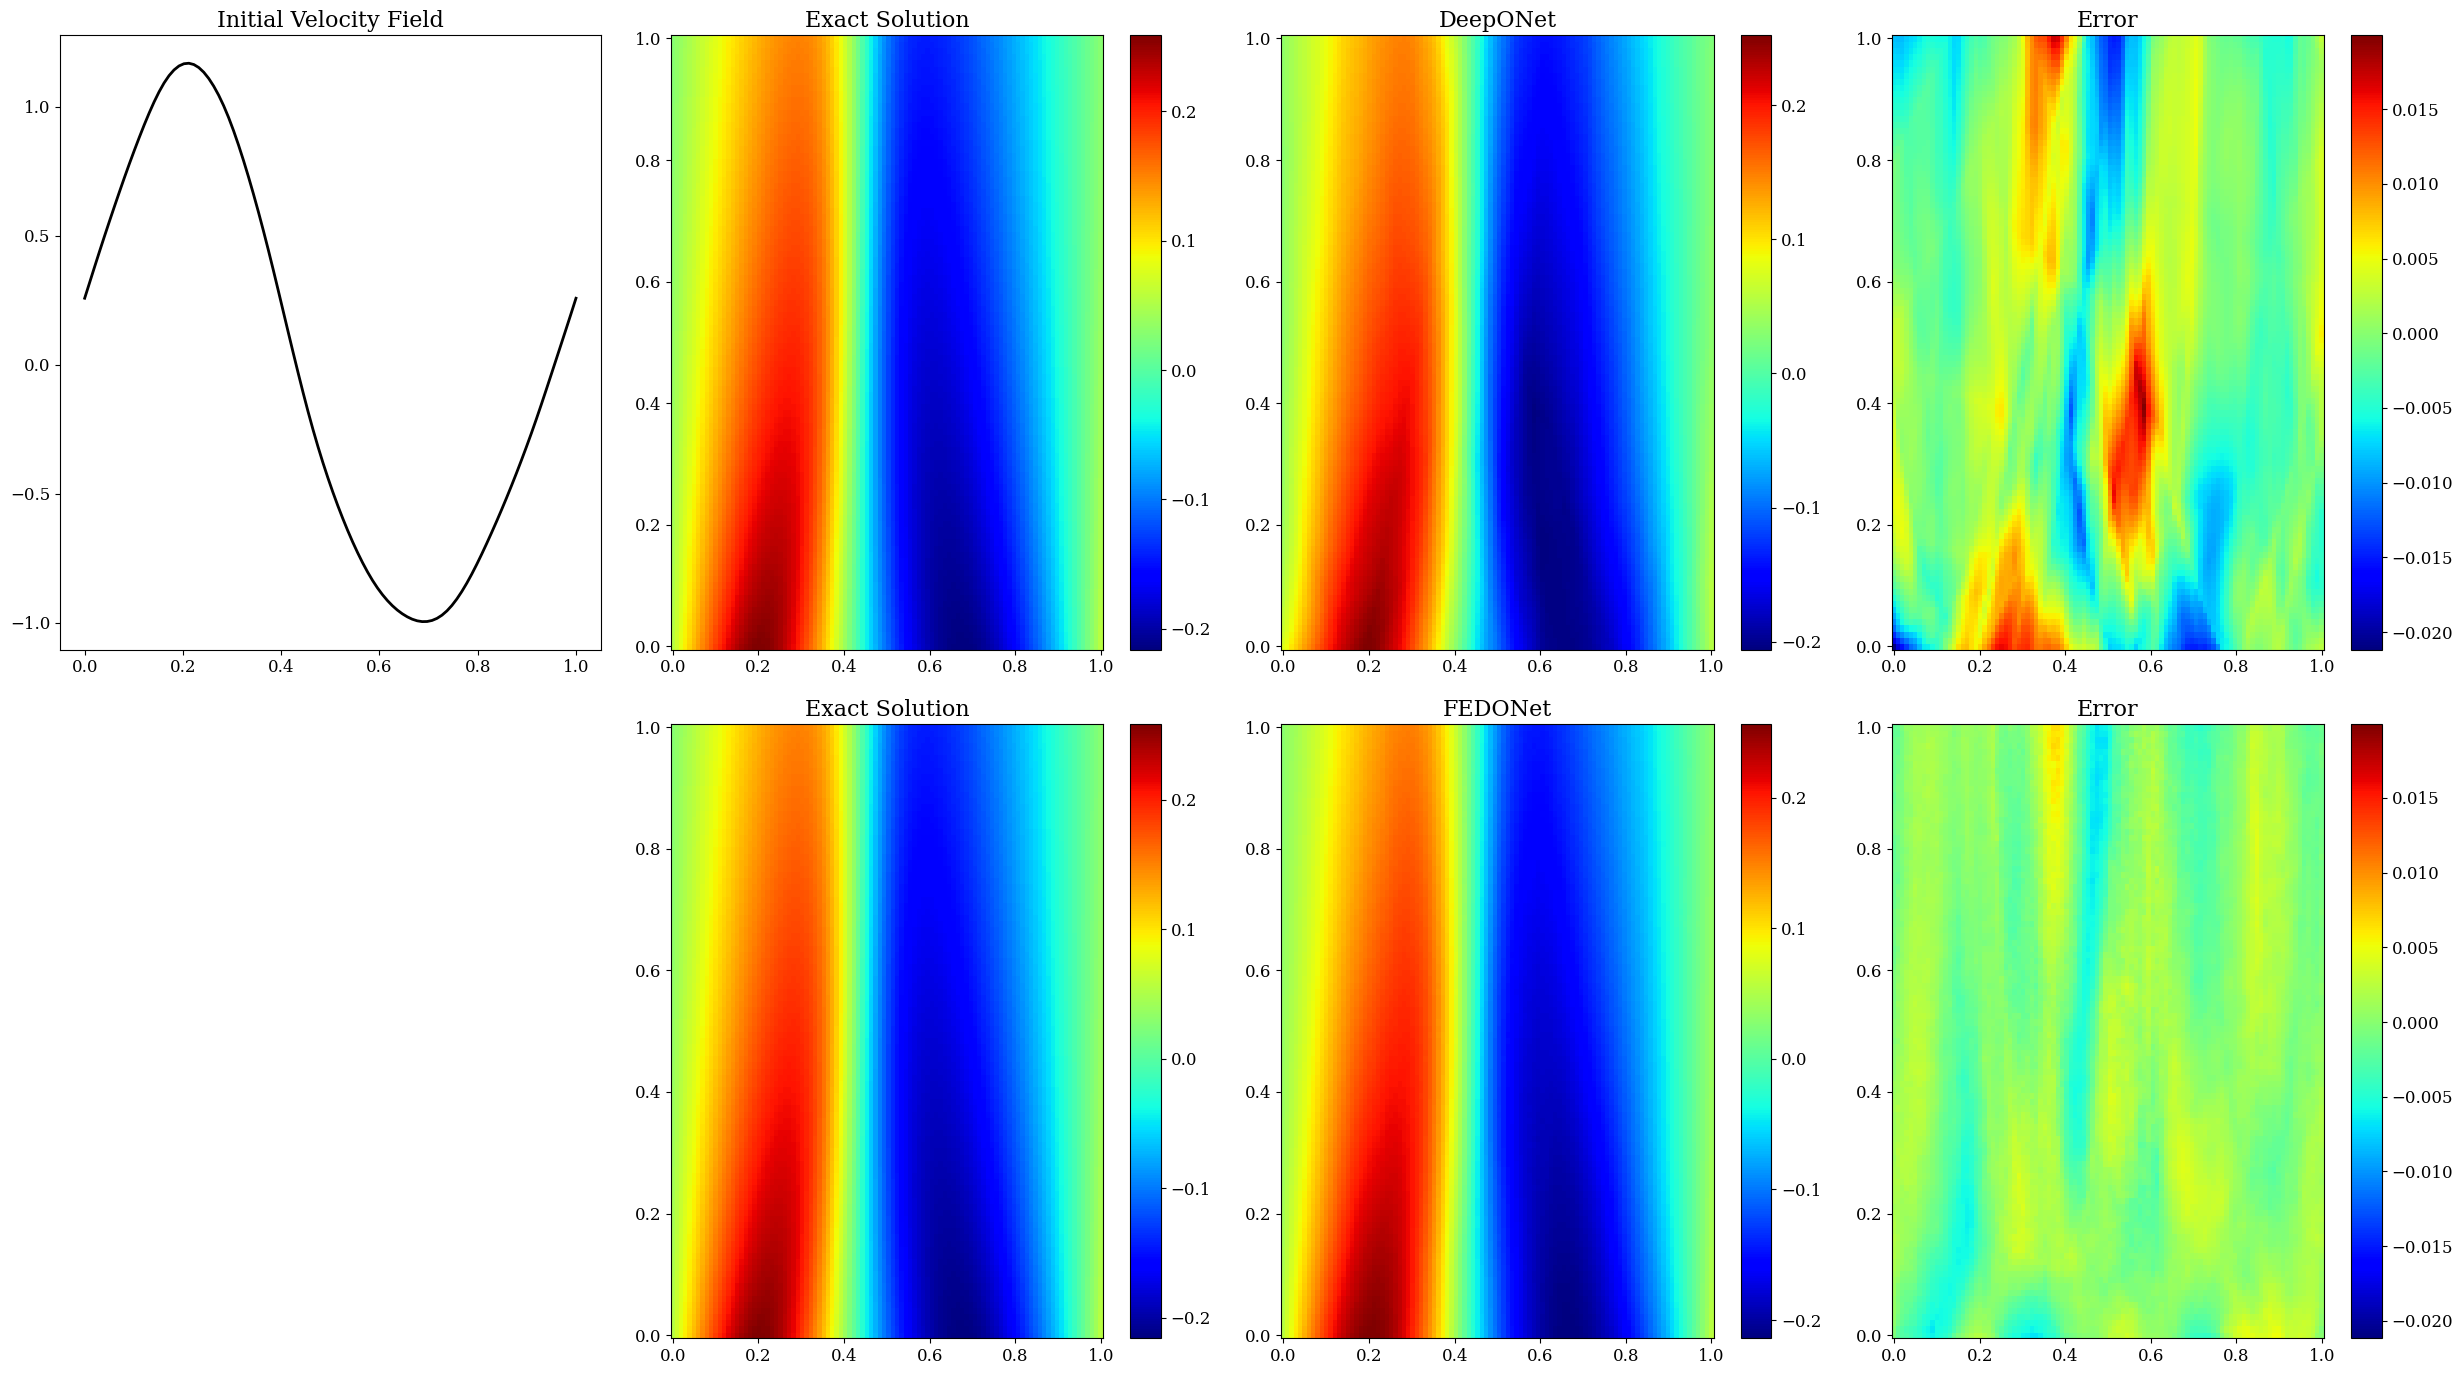

In [3]:
import numpy as np
import matplotlib.pyplot as plt

if 'rel2_fed' not in globals():
    rel2_fed = np.array([np.linalg.norm(GT_test[i] - PRED_fed[i]) / (np.linalg.norm(GT_test[i]) + 1e-12) for i in range(GT_test.shape[0])])

idx = int(np.argmin(rel2_fed))

initial_condition = IC_test
full_solution = GT_test
outputs = PRED_fed
outputs_normal = PRED_van

x = np.linspace(0, 1, full_solution.shape[-1])
t = np.linspace(0, 1, full_solution.shape[-2])
XX, TT = np.meshgrid(x, t, indexing='xy')

error_fed = full_solution[idx] - outputs[idx]
error_van = full_solution[idx] - outputs_normal[idx]
vmin = min(error_fed.min(), error_van.min())
vmax = max(error_fed.max(), error_van.max())

plt.rcParams['image.cmap'] = 'jet'
fig = plt.figure(figsize=(25, 14))

plt.subplot(2, 4, 1)
plt.plot(x, initial_condition[idx], linewidth=2, color='k')
plt.title('Initial Velocity Field')

ax3 = fig.add_subplot(242)
c3 = ax3.pcolor(XX, TT, full_solution[idx])
ax3.set_title('Exact Solution')
fig.colorbar(c3, ax=ax3)

ax4 = fig.add_subplot(247)
c4 = ax4.pcolor(XX, TT, outputs[idx])
ax4.set_title('FEDONet')
fig.colorbar(c4, ax=ax4)

ax5 = fig.add_subplot(248)
c5 = ax5.pcolor(XX, TT, error_fed, vmin=vmin, vmax=vmax)
ax5.set_title('Error')
fig.colorbar(c5, ax=ax5)

ax6 = fig.add_subplot(246)
c6 = ax6.pcolor(XX, TT, full_solution[idx])
ax6.set_title('Exact Solution')
fig.colorbar(c6, ax=ax6)

ax7 = fig.add_subplot(243)
c7 = ax7.pcolor(XX, TT, outputs_normal[idx])
ax7.set_title('DeepONet')
fig.colorbar(c7, ax=ax7)

ax8 = fig.add_subplot(244)
c8 = ax8.pcolor(XX, TT, error_van, vmin=vmin, vmax=vmax)
ax8.set_title('Error')
fig.colorbar(c8, ax=ax8)

plt.tight_layout()
plt.show()


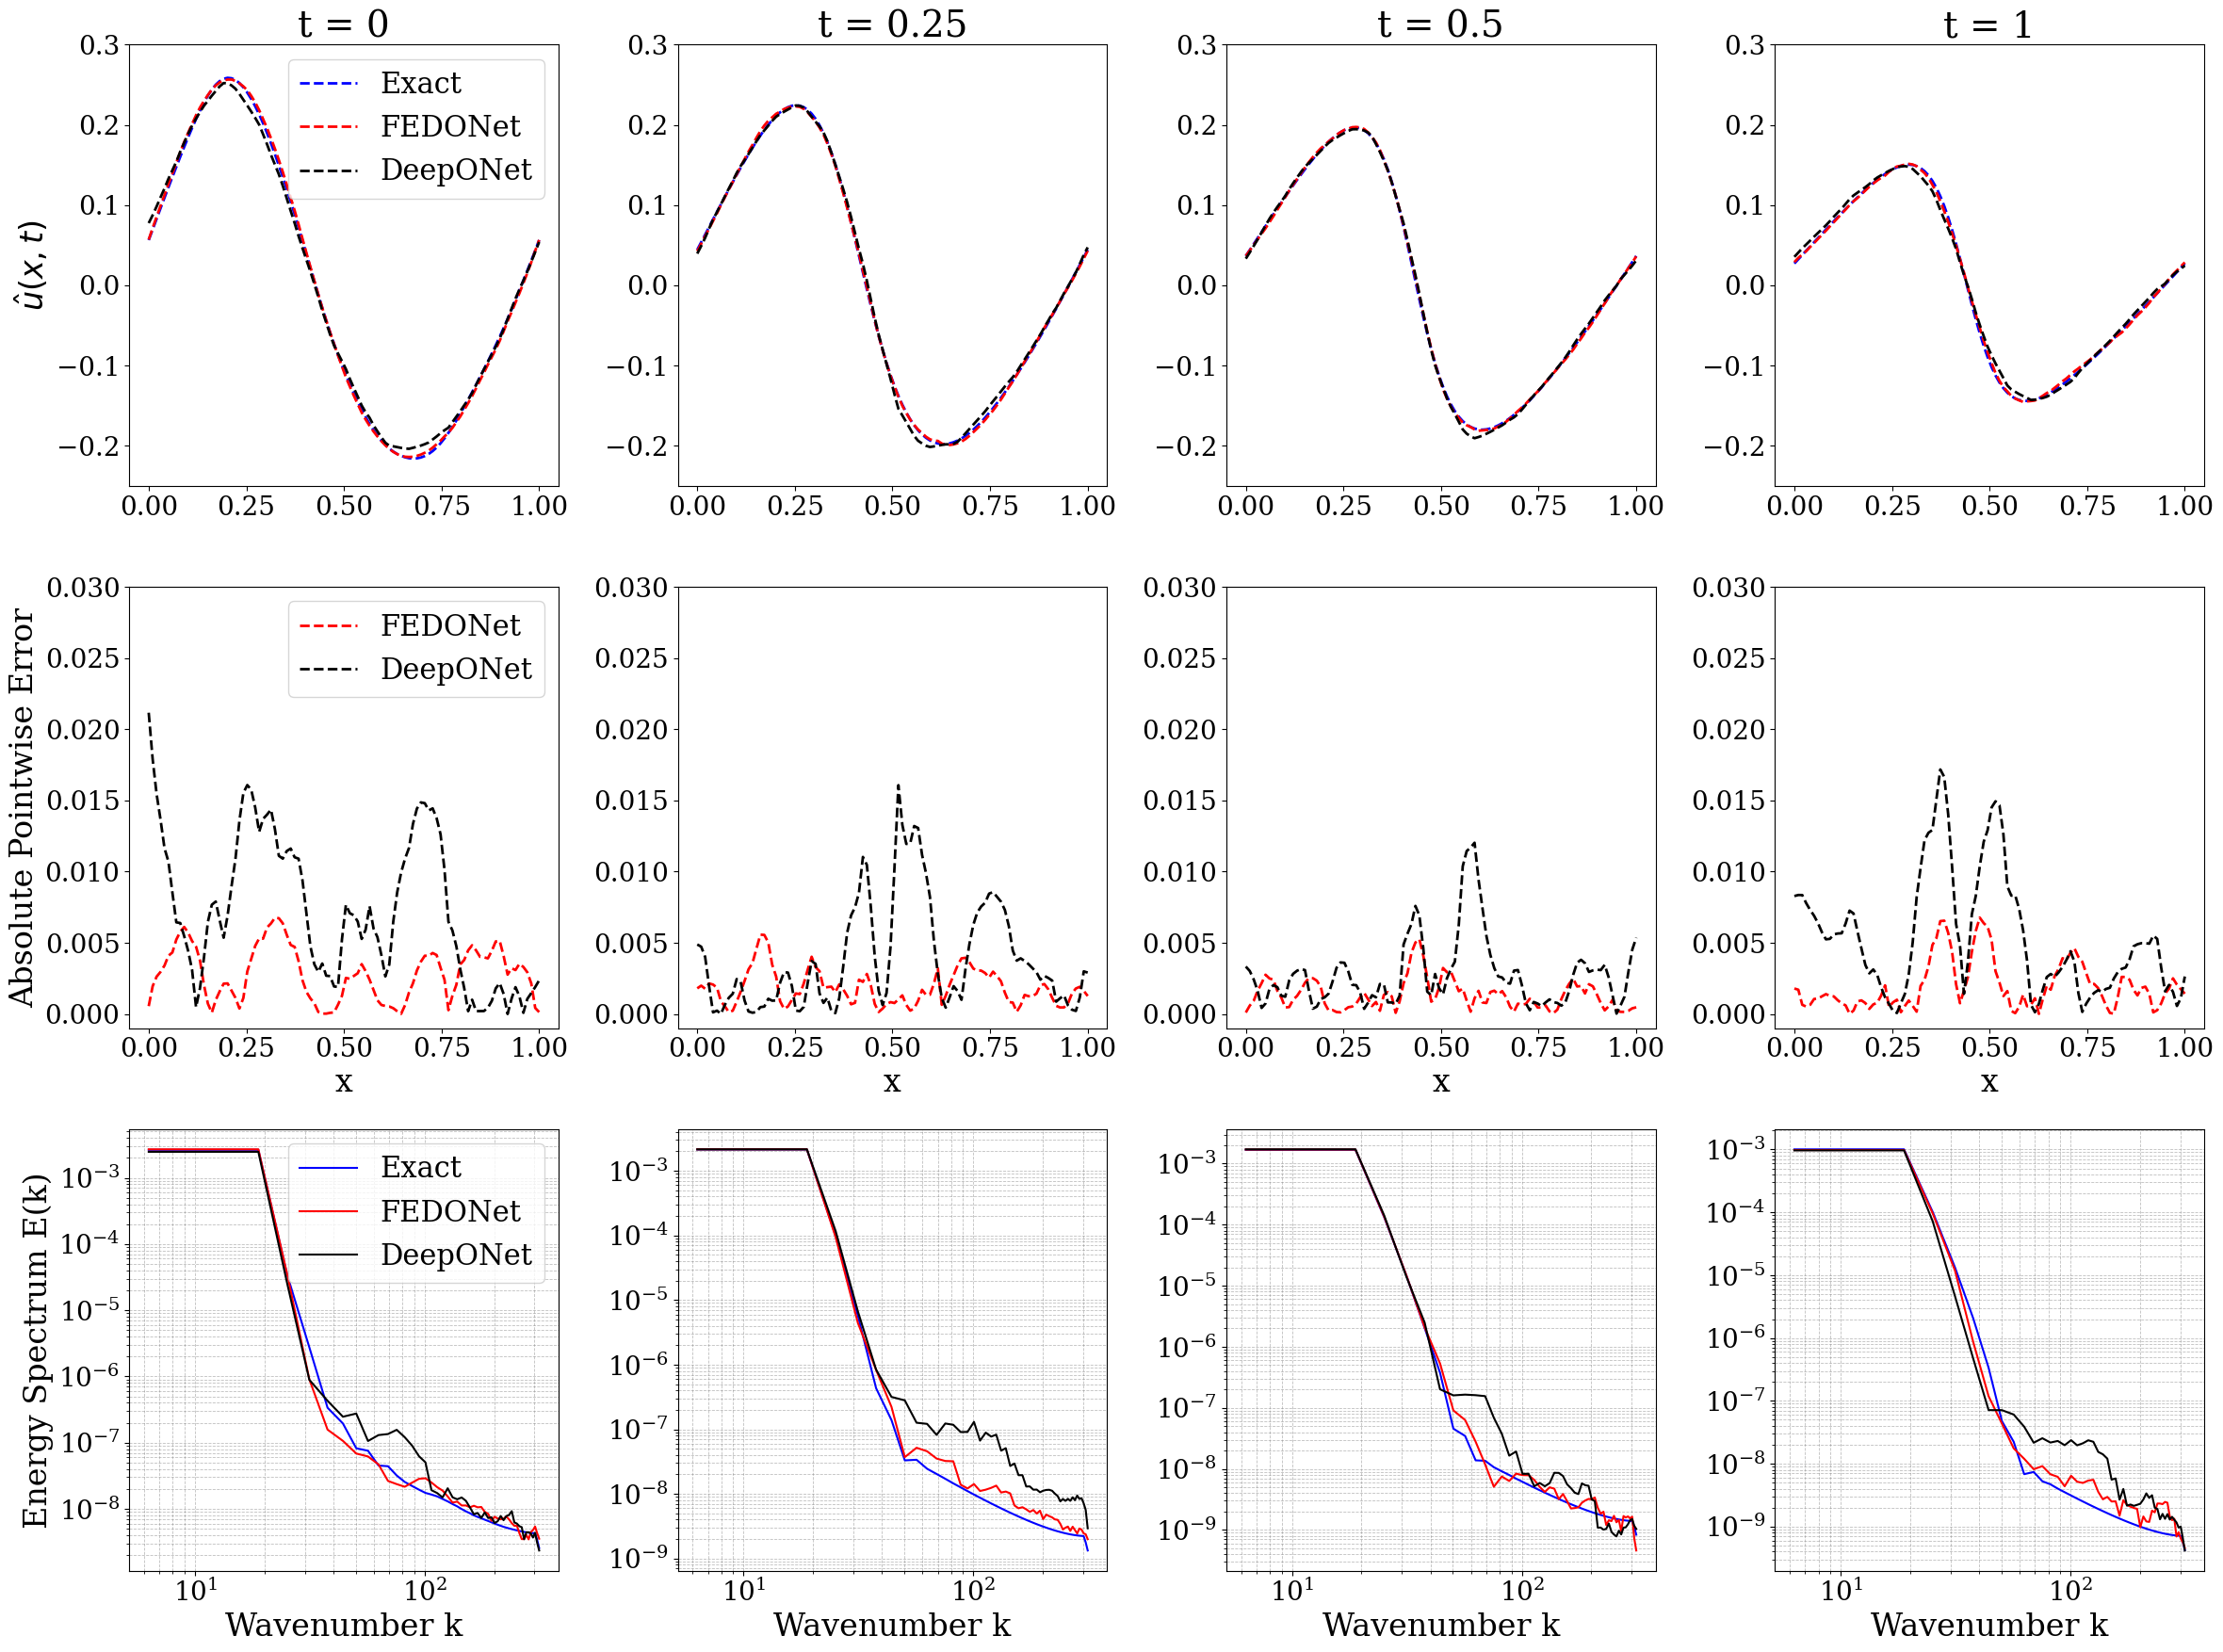

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Increase only font sizes
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

def compute_energy_spectrum_1d(u, L=1.0):
    N = u.shape[0]
    uh = np.fft.rfft(u)
    k = 2 * np.pi * np.fft.rfftfreq(N, d=L / N)
    E = (np.abs(uh) ** 2) / (N ** 2)
    return k[1:], E[1:]

def smooth_spectrum(y, window_len=5):
    if window_len <= 1:
        return y
    kernel = np.ones(window_len) / window_len
    return np.convolve(y, kernel, mode='same')

fig = plt.figure(figsize=(24, 18))
time_steps = [0, 25, 50, -1]
titles = ['t = 0', 't = 0.25', 't = 0.5', 't = 1']

for i, t in enumerate(time_steps):
    ax1 = plt.subplot(3, 4, i + 1)
    ax1.plot(x, full_solution[idx, t, :].squeeze(), linewidth=2, color='b', linestyle='--', label='Exact')
    ax1.plot(x, outputs[idx, t, :].squeeze(), linewidth=2, color='red', linestyle='--', label='FEDONet')
    ax1.plot(x, outputs_normal[idx, t, :].squeeze(), linewidth=2, color='k', linestyle='--', label='DeepONet')
    ax1.set_title(titles[i])
    if i == 0:
        ax1.set_ylabel('$\\hat{u}(x,t)$')
    ax1.set_ylim(-0.25, 0.3)
    if i == 0:
        ax1.legend(loc='upper right')

    ax2 = plt.subplot(3, 4, i + 5)
    ax2.plot(x, np.abs(full_solution[idx, t, :].squeeze() - outputs[idx, t, :].squeeze()), linewidth=2, color='red', linestyle='--', label='FEDONet')
    ax2.plot(x, np.abs(full_solution[idx, t, :].squeeze() - outputs_normal[idx, t, :].squeeze()), linewidth=2, color='k', linestyle='--', label='DeepONet')
    ax2.set_xlabel('x')
    if i == 0:
        ax2.set_ylabel('Absolute Pointwise Error')
        ax2.legend(loc='upper right')
    ax2.set_ylim([-0.001, 0.03])

    k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx, t, :].T)
    k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx, t, :].T)
    k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx, t, :].T)

    ax3 = plt.subplot(3, 4, i + 9)
    ax3.loglog(k_vals, smooth_spectrum(E_vals, window_len=5), 'b-', label='Exact')
    ax3.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier, window_len=5), 'r-', label='FEDONet')
    ax3.loglog(k_vals_normal, smooth_spectrum(E_vals_normal, window_len=5), 'k-', label='DeepONet')
    ax3.set_xlabel("Wavenumber k")
    if i == 0:
        ax3.set_ylabel("Energy Spectrum E(k)")
        ax3.legend(loc="upper right")
    ax3.grid(True, which="both", linestyle="--", linewidth=0.6)

plt.tight_layout()
plt.show()

Noise level = 0.0000 | Mean Rel-L2 = 4.864818e-02 ± 0.00e+00
Noise level = 0.0100 | Mean Rel-L2 = 4.872884e-02 ± 3.72e-05
Noise level = 0.0200 | Mean Rel-L2 = 4.892562e-02 ± 7.16e-05
Noise level = 0.0500 | Mean Rel-L2 = 5.031576e-02 ± 7.72e-05
Noise level = 0.0700 | Mean Rel-L2 = 5.182356e-02 ± 2.86e-04
Noise level = 0.1000 | Mean Rel-L2 = 5.457413e-02 ± 3.19e-04
Noise level = 0.1300 | Mean Rel-L2 = 5.859515e-02 ± 3.76e-04
Noise level = 0.1500 | Mean Rel-L2 = 6.134353e-02 ± 5.60e-04
Noise level = 0.1700 | Mean Rel-L2 = 6.411457e-02 ± 7.53e-04
Noise level = 0.2000 | Mean Rel-L2 = 6.881626e-02 ± 8.26e-04
Noise level = 0.0000 | Mean Rel-L2 = 6.427550e-02 ± 0.00e+00
Noise level = 0.0100 | Mean Rel-L2 = 6.428207e-02 ± 2.56e-05
Noise level = 0.0200 | Mean Rel-L2 = 6.438655e-02 ± 3.89e-05
Noise level = 0.0500 | Mean Rel-L2 = 6.503390e-02 ± 1.04e-04
Noise level = 0.0700 | Mean Rel-L2 = 6.570776e-02 ± 1.98e-04
Noise level = 0.1000 | Mean Rel-L2 = 6.728326e-02 ± 3.22e-04
Noise level = 0.1300 | M

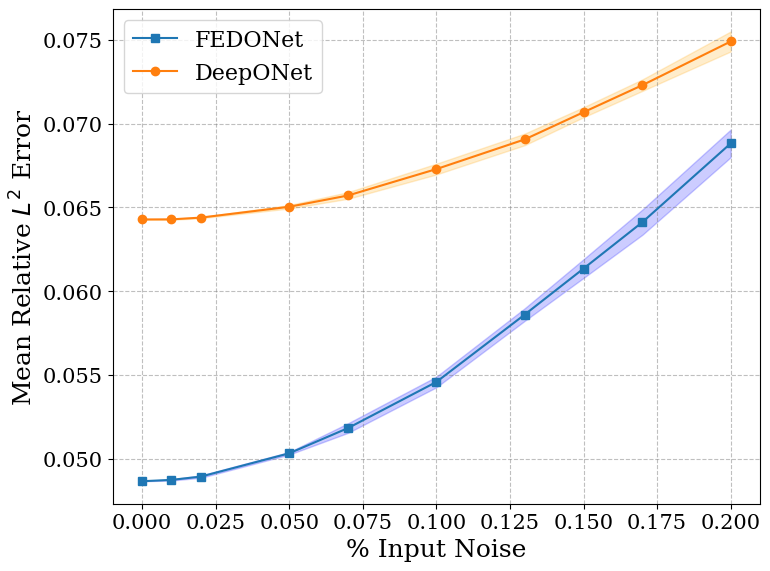

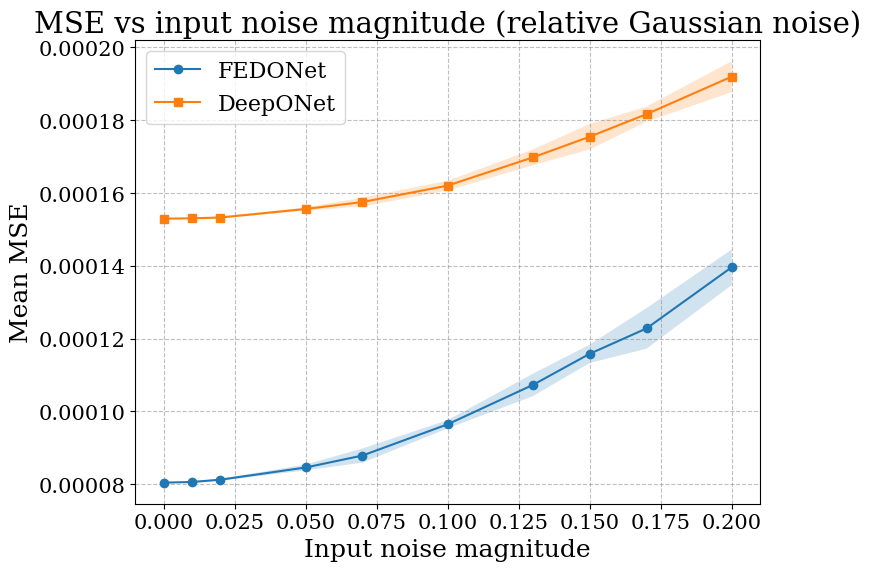

In [5]:
def add_noise_to_ic(ic_clean: np.ndarray, noise_level: float, mode: str = "relative_gaussian"):
    ic_noisy = ic_clean.copy()

    if noise_level == 0.0:
        return ic_noisy

    if mode == "relative_gaussian":
        rms = np.sqrt(np.mean(ic_clean**2, axis=1, keepdims=True)) + 1e-12
        noise = np.random.randn(*ic_clean.shape) * (noise_level * rms)
    elif mode == "absolute_gaussian":
        noise = np.random.randn(*ic_clean.shape) * noise_level
    else:
        raise ValueError(f"Unknown noise mode: {mode}")

    return ic_noisy + noise


class BurgersEvalDataset(Dataset):
    def __init__(self, ic, sol):
        self.ic  = torch.tensor(ic, dtype=torch.float32)
        self.sol = torch.tensor(sol, dtype=torch.float32)

    def __len__(self):
        return self.ic.shape[0]

    def __getitem__(self, i):
        return self.ic[i], self.sol[i]


@torch.no_grad()
def predict_from_arrays(model, ic_norm: np.ndarray, gt_norm: np.ndarray, coords, device, batch_size=128):
    ds = BurgersEvalDataset(ic_norm, gt_norm)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)

    model.eval()
    preds, gts = [], []
    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)
        pred = model(ic, coords.to(device))

        pred_den = denorm_sol(pred).cpu().numpy()
        gt_den   = denorm_sol(gt).cpu().numpy()

        preds.append(pred_den)
        gts.append(gt_den)

    return np.concatenate(gts, axis=0), np.concatenate(preds, axis=0)


def evaluate_noise_sweep(model, X_test_clean, y_test_norm, coords, device,
                         noise_levels, mu_ic, std_ic,
                         mode="relative_gaussian", n_repeats=5, batch_size=128):
    mean_rel_l2 = []
    std_rel_l2  = []
    mean_mse    = []
    std_mse     = []
    all_rel_l2_store = []

    for nl in noise_levels:
        rep_rel = []
        rep_mse = []

        for _ in range(n_repeats):
            X_noisy = add_noise_to_ic(X_test_clean, nl, mode=mode)
            X_noisy_n = (X_noisy - mu_ic) / std_ic

            GT_den, PRED_den = predict_from_arrays(
                model=model,
                ic_norm=X_noisy_n,
                gt_norm=y_test_norm,
                coords=coords,
                device=device,
                batch_size=batch_size
            )

            rels = np.array([
                relative_l2_error_np(GT_den[i], PRED_den[i])
                for i in range(GT_den.shape[0])
            ])
            mses = np.array([
                np.mean((GT_den[i] - PRED_den[i])**2)
                for i in range(GT_den.shape[0])
            ])

            rep_rel.append(rels.mean())
            rep_mse.append(mses.mean())

        rep_rel = np.array(rep_rel)
        rep_mse = np.array(rep_mse)

        mean_rel_l2.append(rep_rel.mean())
        std_rel_l2.append(rep_rel.std())
        mean_mse.append(rep_mse.mean())
        std_mse.append(rep_mse.std())
        all_rel_l2_store.append(rep_rel)

        print(f"Noise level = {nl:.4f} | Mean Rel-L2 = {rep_rel.mean():.6e} ± {rep_rel.std():.2e}")

    results = {
        "noise_levels": np.array(noise_levels),
        "mean_rel_l2": np.array(mean_rel_l2),
        "std_rel_l2": np.array(std_rel_l2),
        "mean_mse": np.array(mean_mse),
        "std_mse": np.array(std_mse),
        "all_rel_l2": np.array(all_rel_l2_store, dtype=object)
    }
    return results


def plot_noise_vs_error(results_fed, results_van=None, title_suffix=""):
    nl = results_fed["noise_levels"]
    plt.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 21,
        'axes.labelsize': 18,
        'xtick.labelsize': 15,
        'ytick.labelsize': 15,
        'legend.fontsize': 16
    })

    plt.figure(figsize=(8, 6))
    plt.plot(nl, results_fed["mean_rel_l2"], marker='s', label='FEDONet')
    plt.fill_between(
        nl,
        results_fed["mean_rel_l2"] - results_fed["std_rel_l2"],
        results_fed["mean_rel_l2"] + results_fed["std_rel_l2"], color='blue',
        alpha=0.2
    )

    if results_van is not None:
        plt.plot(nl, results_van["mean_rel_l2"], marker='o', label='DeepONet')
        plt.fill_between(
            nl,
            results_van["mean_rel_l2"] - results_van["std_rel_l2"],
            results_van["mean_rel_l2"] + results_van["std_rel_l2"], color='orange',
            alpha=0.2
        )

    plt.xlabel("% Input Noise")
    plt.ylabel("Mean Relative $L^2$ Error")
    # plt.title(f"Prediction error vs input noise magnitude{title_suffix}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_noise_vs_mse(results_fed, results_van=None, title_suffix=""):
    
    nl = results_fed["noise_levels"]

    plt.figure(figsize=(8, 6))
    plt.plot(nl, results_fed["mean_mse"], marker='o', label='FEDONet')
    plt.fill_between(
        nl,
        results_fed["mean_mse"] - results_fed["std_mse"],
        results_fed["mean_mse"] + results_fed["std_mse"],
        alpha=0.2
    )

    if results_van is not None:
        plt.plot(nl, results_van["mean_mse"], marker='s', label='DeepONet')
        plt.fill_between(
            nl,
            results_van["mean_mse"] - results_van["std_mse"],
            results_van["mean_mse"] + results_van["std_mse"],
            alpha=0.2
        )

    plt.xlabel("Input noise magnitude")
    plt.ylabel("Mean MSE")
    plt.title(f"MSE vs input noise magnitude{title_suffix}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
# ============================================================
# Noise robustness experiment: error vs input noise magnitude
# ============================================================

# Recommended: relative Gaussian noise as a fraction of IC RMS
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.07, 0.10, 0.13, 0.15, 0.17, 0.20]
n_repeats = 10

results_fed = evaluate_noise_sweep(
    model=fedonet,
    X_test_clean=X_test,        # clean, unnormalized ICs
    y_test_norm=y_test_n,       # normalized GT solution
    coords=coords,
    device=device,
    noise_levels=noise_levels,
    mu_ic=mu_ic,
    std_ic=std_ic,
    mode="relative_gaussian",
    n_repeats=n_repeats,
    batch_size=batch_size
)

results_van = evaluate_noise_sweep(
    model=deeponet,
    X_test_clean=X_test,
    y_test_norm=y_test_n,
    coords=coords,
    device=device,
    noise_levels=noise_levels,
    mu_ic=mu_ic,
    std_ic=std_ic,
    mode="relative_gaussian",
    n_repeats=n_repeats,
    batch_size=batch_size
)

plot_noise_vs_error(results_fed, results_van, title_suffix=" (relative Gaussian noise)")
plot_noise_vs_mse(results_fed, results_van, title_suffix=" (relative Gaussian noise)")

In [6]:
print("\nFEDONet Noise Robustness Summary")
print("-" * 60)
for nl, m, s in zip(results_fed["noise_levels"], results_fed["mean_rel_l2"], results_fed["std_rel_l2"]):
    print(f"Noise = {nl:>5.2f} | Rel-L2 = {m:.6e} ± {s:.2e}")

print("\nDeepONet Noise Robustness Summary")
print("-" * 60)
for nl, m, s in zip(results_van["noise_levels"], results_van["mean_rel_l2"], results_van["std_rel_l2"]):
    print(f"Noise = {nl:>5.2f} | Rel-L2 = {m:.6e} ± {s:.2e}")


FEDONet Noise Robustness Summary
------------------------------------------------------------
Noise =  0.00 | Rel-L2 = 4.864818e-02 ± 0.00e+00
Noise =  0.01 | Rel-L2 = 4.872884e-02 ± 3.72e-05
Noise =  0.02 | Rel-L2 = 4.892562e-02 ± 7.16e-05
Noise =  0.05 | Rel-L2 = 5.031576e-02 ± 7.72e-05
Noise =  0.07 | Rel-L2 = 5.182356e-02 ± 2.86e-04
Noise =  0.10 | Rel-L2 = 5.457413e-02 ± 3.19e-04
Noise =  0.13 | Rel-L2 = 5.859515e-02 ± 3.76e-04
Noise =  0.15 | Rel-L2 = 6.134353e-02 ± 5.60e-04
Noise =  0.17 | Rel-L2 = 6.411457e-02 ± 7.53e-04
Noise =  0.20 | Rel-L2 = 6.881626e-02 ± 8.26e-04

DeepONet Noise Robustness Summary
------------------------------------------------------------
Noise =  0.00 | Rel-L2 = 6.427550e-02 ± 0.00e+00
Noise =  0.01 | Rel-L2 = 6.428207e-02 ± 2.56e-05
Noise =  0.02 | Rel-L2 = 6.438655e-02 ± 3.89e-05
Noise =  0.05 | Rel-L2 = 6.503390e-02 ± 1.04e-04
Noise =  0.07 | Rel-L2 = 6.570776e-02 ± 1.98e-04
Noise =  0.10 | Rel-L2 = 6.728326e-02 ± 3.22e-04
Noise =  0.13 | Rel-L2 = 

Mean Rel-L2 (20% noise)
FEDONet : 0.050078407
DeepONet: 0.065000124


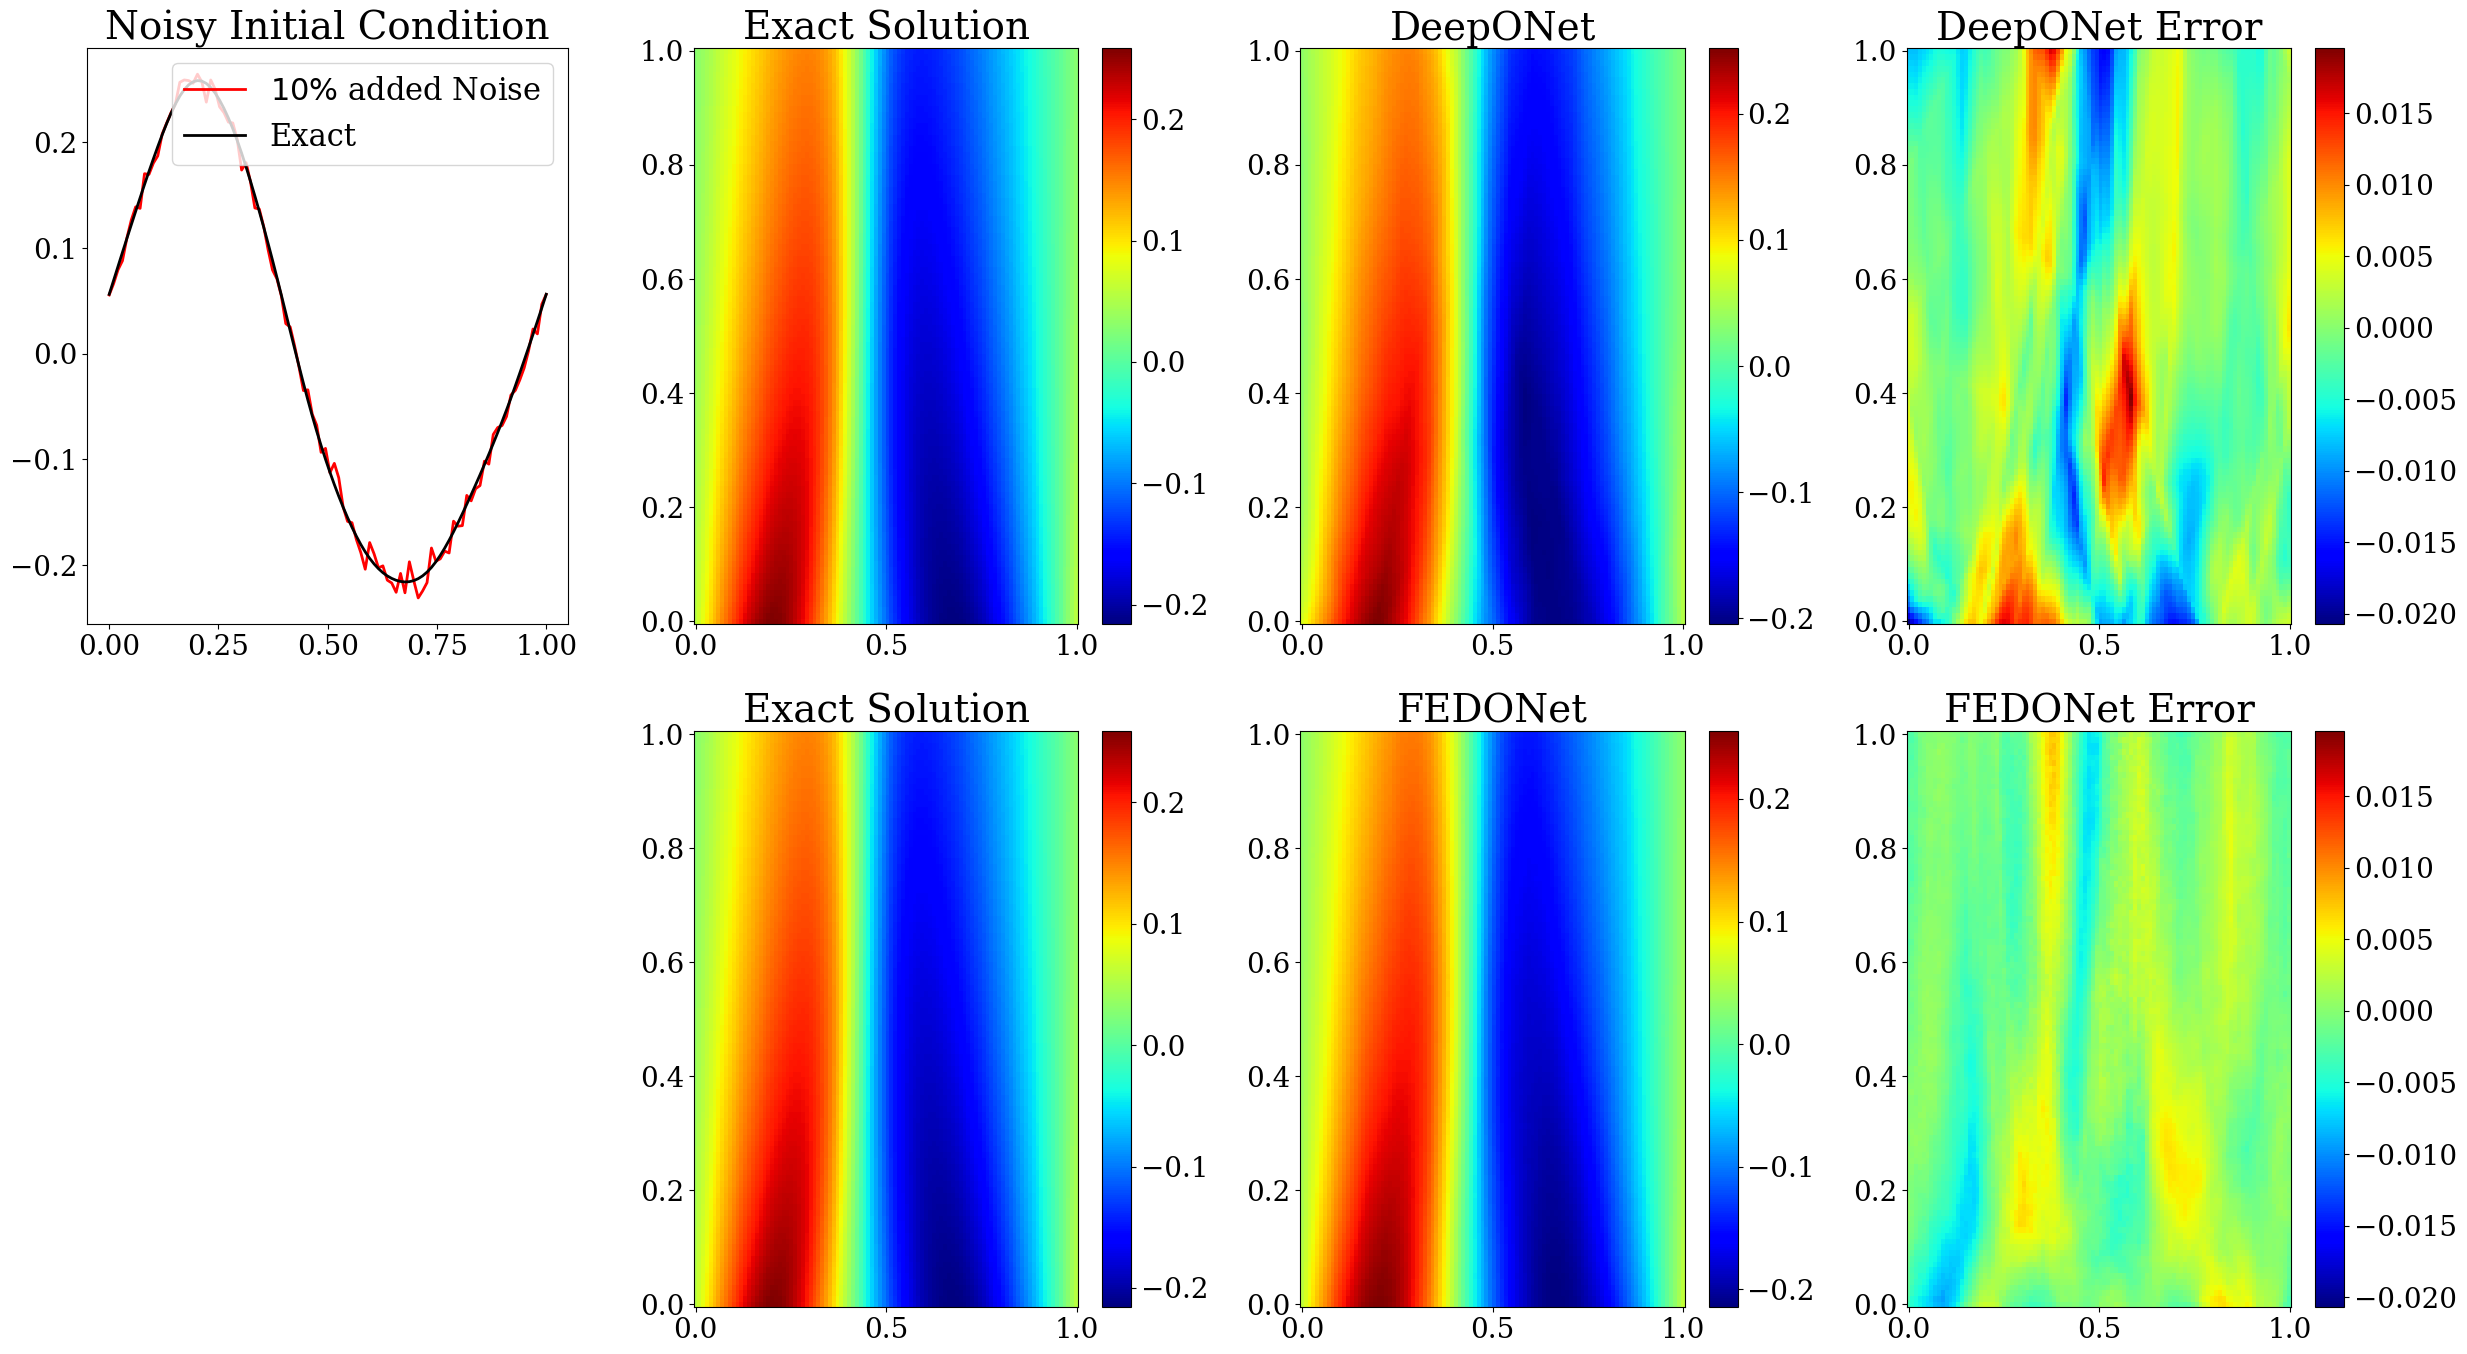

In [7]:
# ============================================================
# 20% NOISE TEST VISUALIZATION
# ============================================================

noise_level = 0.05   # 20% noise

# ---- Add noise to clean test IC ----
rms = np.sqrt(np.mean(X_test**2, axis=1, keepdims=True)) + 1e-12
noise = np.random.randn(*X_test.shape) * (noise_level * rms)

IC_test_noisy = X_test + noise

# ---- Normalize using training statistics ----
IC_test_noisy_n = (IC_test_noisy - mu_ic) / std_ic

# ---- Predict using noisy IC ----
GT_test_noisy, PRED_fed_noisy = predict_from_arrays(
    fedonet,
    IC_test_noisy_n,
    y_test_n,
    coords,
    device
)

_, PRED_van_noisy = predict_from_arrays(
    deeponet,
    IC_test_noisy_n,
    y_test_n,
    coords,
    device
)

# ---- Compute Rel L2 errors ----
rel2_fed_noisy = np.array([
    np.linalg.norm(GT_test_noisy[i] - PRED_fed_noisy[i]) /
    (np.linalg.norm(GT_test_noisy[i]) + 1e-12)
    for i in range(GT_test_noisy.shape[0])
])

rel2_van_noisy = np.array([
    np.linalg.norm(GT_test_noisy[i] - PRED_van_noisy[i]) /
    (np.linalg.norm(GT_test_noisy[i]) + 1e-12)
    for i in range(GT_test_noisy.shape[0])
])

print("Mean Rel-L2 (20% noise)")
print("FEDONet :", rel2_fed_noisy.mean())
print("DeepONet:", rel2_van_noisy.mean())

# ---- Choose best sample (lowest FEDONet error) ----
idx = int(np.argmin(rel2_fed_noisy))

initial_condition_clean = X_test
initial_condition_noisy = IC_test_noisy

full_solution = GT_test_noisy
outputs_fed = PRED_fed_noisy
outputs_van = PRED_van_noisy

# ---- Grid ----
x = np.linspace(0, 1, full_solution.shape[-1])
t = np.linspace(0, 1, full_solution.shape[-2])
XX, TT = np.meshgrid(x, t, indexing='xy')

# ---- Errors ----
error_fed = full_solution[idx] - outputs_fed[idx]
error_van = full_solution[idx] - outputs_van[idx]

vmin = min(error_fed.min(), error_van.min())
vmax = max(error_fed.max(), error_van.max())

# ============================================================
# Plot
# ============================================================

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

plt.rcParams['image.cmap'] = 'jet'
fig = plt.figure(figsize=(25, 14))

# # ---- Clean IC ----
# plt.subplot(2,4,1)
# 
# plt.title('Clean Initial Condition')

# ---- Noisy IC ----
plt.subplot(2,4,1)
plt.plot(x, initial_condition_noisy[idx], linewidth=2, color='r', label='$10\\%$ added Noise')
plt.plot(x, initial_condition_clean[idx], linewidth=2, color='k',label='Exact')
plt.legend(loc='upper right', frameon=True)
plt.title('Noisy Initial Condition')

# ---- Exact ----
ax1 = fig.add_subplot(242)
c1 = ax1.pcolor(XX, TT, full_solution[idx])
ax1.set_title('Exact Solution')
fig.colorbar(c1, ax=ax1)

ax1 = fig.add_subplot(246)
c1 = ax1.pcolor(XX, TT, full_solution[idx])
ax1.set_title('Exact Solution')
fig.colorbar(c1, ax=ax1)

# ---- FEDONet ----
ax2 = fig.add_subplot(247)
c2 = ax2.pcolor(XX, TT, outputs_fed[idx])
ax2.set_title('FEDONet')
fig.colorbar(c2, ax=ax2)

# ---- FEDONet Error ----
ax3 = fig.add_subplot(248)
c3 = ax3.pcolor(XX, TT, error_fed, vmin=vmin, vmax=vmax)
ax3.set_title('FEDONet Error')
fig.colorbar(c3, ax=ax3)

# ---- DeepONet ----
ax5 = fig.add_subplot(243)
c5 = ax5.pcolor(XX, TT, outputs_van[idx])
ax5.set_title('DeepONet')
fig.colorbar(c5, ax=ax5)

# ---- DeepONet Error ----
ax6 = fig.add_subplot(244)
c6 = ax6.pcolor(XX, TT, error_van, vmin=vmin, vmax=vmax)
ax6.set_title('DeepONet Error')
fig.colorbar(c6, ax=ax6)

plt.tight_layout()
plt.show()

In [8]:
print(f"✅ Models evaluated successfully!")
print(f"Test dataset contains {GT_test.shape[0]} samples.")
print(f"Each sample has shape: {GT_test.shape[1:]} (time × space grid)")

fed_mean = rel2_fed.mean()
van_mean = rel2_van.mean()
print(f"FEDONet  → mean rel L2 = {fed_mean:.4f}")
print(f"DeepONet → mean rel L2 = {van_mean:.4f}")


✅ Models evaluated successfully!
Test dataset contains 250 samples.
Each sample has shape: (100, 100) (time × space grid)
FEDONet  → mean rel L2 = 0.0486
DeepONet → mean rel L2 = 0.0643


FEDONet  → mean rel L2 = 0.048648, std = 0.034494
DeepONet → mean rel L2 = 0.064275, std = 0.037952


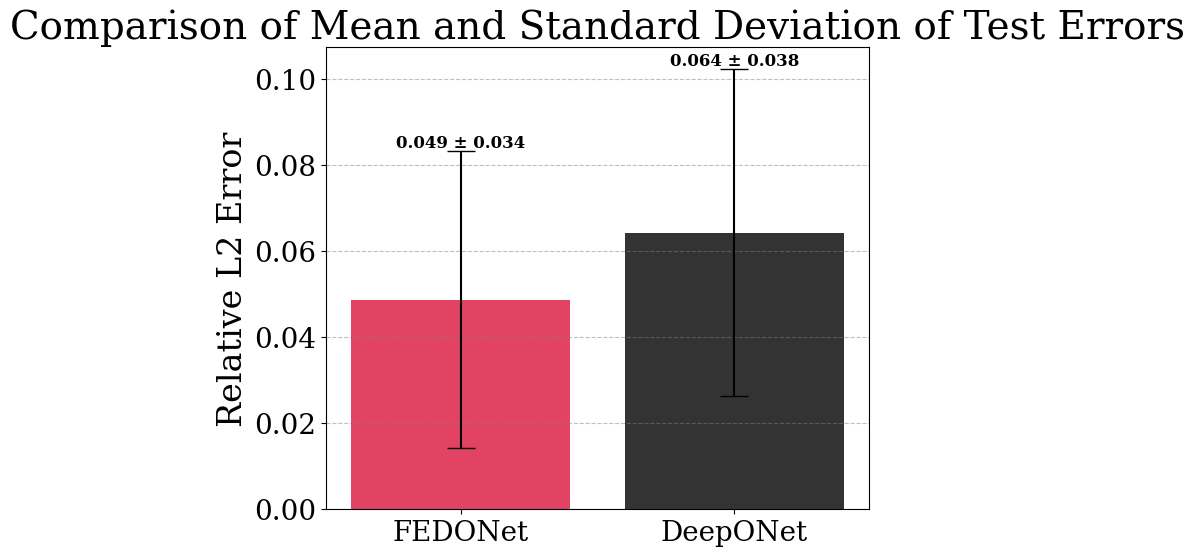

In [9]:
import matplotlib.pyplot as plt
import numpy as np

mean_fed, std_fed = np.mean(rel2_fed), np.std(rel2_fed)
mean_van, std_van = np.mean(rel2_van), np.std(rel2_van)

print("==========================================")
print(f"FEDONet  → mean rel L2 = {mean_fed:.6f}, std = {std_fed:.6f}")
print(f"DeepONet → mean rel L2 = {mean_van:.6f}, std = {std_van:.6f}")
print("==========================================")

plt.figure(figsize=(7,6))
models = ['FEDONet', 'DeepONet']
means = [mean_fed, mean_van]
stds  = [std_fed, std_van]

bars = plt.bar(models, means, yerr=stds, capsize=10, color=['crimson','black'], alpha=0.8)
plt.ylabel('Relative L2 Error')
plt.title('Comparison of Mean and Standard Deviation of Test Errors')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, mean, std in zip(bars, means, stds):
    plt.text(bar.get_x() + bar.get_width()/2, mean + std + 0.001,
             f"{mean:.3f} ± {std:.3f}", ha='center', fontsize=12, fontweight='bold')

plt.show()
